Connected to adventofcode2025 (Python 3.14.1)

In [224]:
from matplotlib import pyplot as plt
from pathlib import Path

In [225]:
x = (1, 3, 3, 1)

In [226]:
y = (1, 1, 4, 4)

In [227]:
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

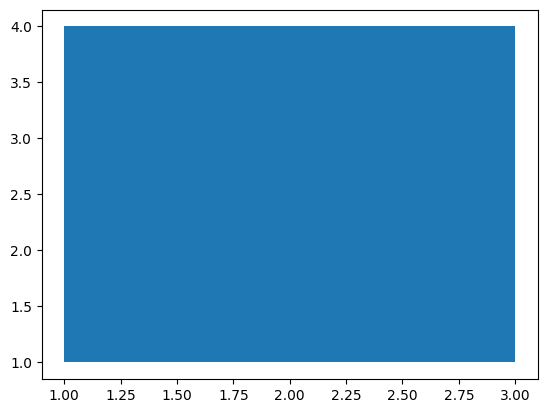

In [228]:
plt.fill(x, y)

In [229]:
from pathlib import Path

with Path("sample").open() as file:
    for line in file.readlines():
        coords = line.strip().split(",")
        print(coords)

['7', '1']
['11', '1']
['11', '7']
['9', '7']
['9', '5']
['2', '5']
['2', '3']
['7', '3']


In [230]:
from pathlib import Path
from shapely.geometry import Point, Polygon


xs: list[int] = []
ys: list[int] = []
polygon_points: list[tuple[int]] = []
polygon: Polygon = None

with Path("sample").open() as file:
    for line in file.readlines():
        coords = line.strip().split(",")
        print(coords)
        xs.append(int(coords[0]))
        ys.append(int(coords[1]))
        polygon_points.append((int(coords[0]), int(coords[1])))
    polygon = Polygon(polygon_points)
        

['7', '1']
['11', '1']
['11', '7']
['9', '7']
['9', '5']
['2', '5']
['2', '3']
['7', '3']


In [231]:
xs

[7, 11, 11, 9, 9, 2, 2, 7]

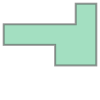

In [232]:
polygon

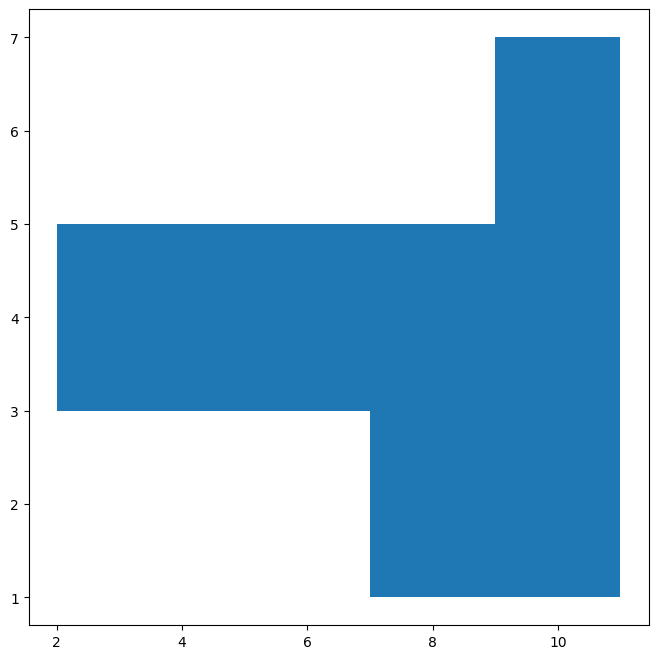

In [233]:
plt.figure(figsize=(8,8))
plt.fill(xs, ys)
plt.show()

In [234]:
from itertools import pairwise

def check_crossing(p1, p2, segment) -> bool:
    crosses = False

    # check horizontal or vertical?
    if p1[1] == p2[1] and segment[0][1] != segment[1][1]: # same y coordinate -> check horizontal crossing
        sorted_ys = sorted((segment[0][1], segment[1][1]))
        sorted_xs = sorted((p1[0], p2[0]))
        if sorted_ys[0] < p1[1] < sorted_ys[1] \
            and sorted_xs[0] < segment[0][0] < sorted_xs[1]:
            crosses = True
    elif p1[0] == p2[0] and segment[0][0] != segment[1][0]: # same x -> vertical crossing
        sorted_ys = sorted((p1[1], p2[1]))
        sorted_xs = sorted((segment[0][0], segment[1][0]))
        if sorted_ys[0] < segment[0][1] < sorted_ys[1] \
            and sorted_xs[0] < p1[0] < sorted_xs[1]:
            crosses = True
    else:
        pass
    return crosses


def crosses_edge(p1: tuple[int], p2: tuple[int], xs, ys):
    crossing: bool = False
    for line in pairwise(zip(xs, ys)):
        crossing = crossing | check_crossing(p1, p2, line)
    
    # check polygon segment last point to first
    crossing = crossing | check_crossing(p1, p2, ((xs[-1], ys[-1]), (xs[0], ys[0])))

    return crossing
    

# check vertical
# assert check_crossing((2, 5), (10,5), ((9, 5), (9, 7))) is True
assert check_crossing((4, 1), (4, 2), ((2, 3), (7, 3))) is False
assert check_crossing((4, 1), (4, 6), ((2, 3), (7, 3))) is True
assert check_crossing((2, 3), (2, 5), ((2, 3), (7, 3))) is False
# assert check_crossing((2, 2), (2, 4), ((2, 3), (7, 3))) is True
assert check_crossing((4, 1), (4, 4), ((2, 3), (7, 3))) is True
# check horizontal
assert check_crossing((4, 2), (5, 2), ((7, 3), (7, 1))) is False
assert check_crossing((4, 2), (9, 2), ((7, 3), (7, 1))) is True
assert check_crossing((4, 2), (20, 2), ((7, 3), (7, 1))) is True

# test on whole polygon
# vertical
assert crosses_edge((4, 1), (4, 2), xs, ys) is False
assert crosses_edge((4, 1), (4, 6), xs, ys) is True
assert crosses_edge((4, 1), (4, 4), xs, ys) is True
# horizontal
assert crosses_edge((4, 2), (5, 2), xs, ys) is False
assert crosses_edge((4, 2), (9, 2), xs, ys) is True
assert crosses_edge((4, 2), (20, 2), xs, ys) is True


In [235]:
# this code is modified from part 1
from pathlib import Path
from shapely.geometry import Point, Polygon

def is_valid(p1, p2, xs, ys, polygon) -> bool:
    crossings: list[bool] = []
    outside: list[bool] = []

    n1 = (p1[0], p1[1])
    n2 = (p1[0], p2[1])
    n3 = (p2[0], p2[1])
    n4 = (p2[0], p1[1])

    for q1, q2 in ((n1, n2), (n2, n3), (n3, n4), (n4, n1)):
        crossings.append(crosses_edge(q1, q2, xs, ys))

    # any point outside the polygon?
    for n in (n1, n2, n3, n4):
        point: Point = Point(n)
        if (not point.within(polygon)) and (not point.touches(polygon)):
            outside.append(True)


    if any(crossings) or any(outside):
        return False
    else:
        return True
    

assert is_valid((2,3), (4,5), xs, ys, polygon) is True
assert is_valid((2,3), (4,7), xs, ys, polygon) is False

xs: list[int] = []
ys: list[int] = []
polygon_points: list[tuple[int]] = []
polygon: Polygon = None

with Path("input").open() as file:
    for line in file.readlines():
        coords = line.strip().split(",")
        xs.append(int(coords[0]))
        ys.append(int(coords[1]))
        polygon_points.append((int(coords[0]), int(coords[1])))
    polygon = Polygon(polygon_points)

# (83829, 85218) (12867, 18347)
# (48515, 98075) (1725, 52189)
# (5529, 67739) (94710, 50238)
assert is_valid((5529, 67739), (94710, 50238), xs, ys, polygon) is True
assert is_valid((48515, 98075), (1725, 52189), xs, ys, polygon) is False
# assert is_valid((83829, 85218), (12867, 18347), xs, ys, polygon) is False
# assert is_valid((83829, 85218), (16274, 14908), xs, ys, polygon) is False
# assert is_valid((2,3), (4,7), xs, ys) is False


def find_largest_inside_rectanlge(path: str, xs, ys, polygon:Polygon) -> int:
    tiles: list[tuple[int]] = []

    with Path(path).open() as file:
        for line in file.readlines():
            tiles.append(line.strip().split(","))

    largest: int = 0
    
    for first in tiles:
        first = (int(first[0]), int(first[1]))
        for second in tiles:
            second = (int(second[0]), int(second[1]))
            area = (abs(first[0] - second[0]) + 1) * \
                (abs(first[1] - second[1]) + 1)
            if area > largest:
                if is_valid(first, second, xs, ys, polygon):
                    largest = area
                    print(first, second, f"{largest:,}", largest)

    return largest

for path in ("sample", "input"):
    with Path(path).open() as file:
        xs: list[int] = []
        ys: list[int] = []
        polygon_points: list[tuple[int]] = []

        polygon = Polygon(polygon_points)
        for line in file.readlines():
            coords = line.strip().split(",")
            polygon_points.append((int(coords[0]), int(coords[1])))
            xs.append(int(coords[0]))
            ys.append(int(coords[1]))

        polygon = Polygon(polygon_points)
        result = find_largest_inside_rectanlge(path, xs, ys, polygon)
        print(f"{result=}")
        if path == "sample":
            assert 24 == result

        print(f"{path}: {result}")



(7, 1) (7, 1) 1 1
(7, 1) (11, 1) 5 5
(7, 1) (9, 5) 15 15
(11, 1) (9, 7) 21 21
(9, 5) (2, 3) 24 24
result=24
sample: 24
(97879, 50255) (97879, 50255) 1 1
(97879, 50255) (97879, 51476) 1,222 1222
(97879, 50255) (97529, 53875) 1,270,971 1270971
(97879, 50255) (2561, 53361) 296,156,133 296156133
(97879, 50255) (2509, 53361) 296,317,697 296317697
(5529, 67739) (94710, 50238) 1,560,863,364 1560863364
(4890, 67739) (94710, 50238) 1,572,047,142 1572047142
result=1572047142
input: 1572047142


In [16]:
from pathlib import Path
xs, ys = [], []

with Path("input").open() as file:
    for line in file.readlines():
        coords = line.strip().split(",")
        xs.append(int(coords[0]))
        ys.append(int(coords[1]))
        


In [17]:
# %%
# %%
from pathlib import Path
xs, ys = [], []

with Path("input").open() as file:
    for line in file.readlines():
        coords = line.strip().split(",")
        xs.append(int(coords[0]))
        ys.append(int(coords[1]))
        

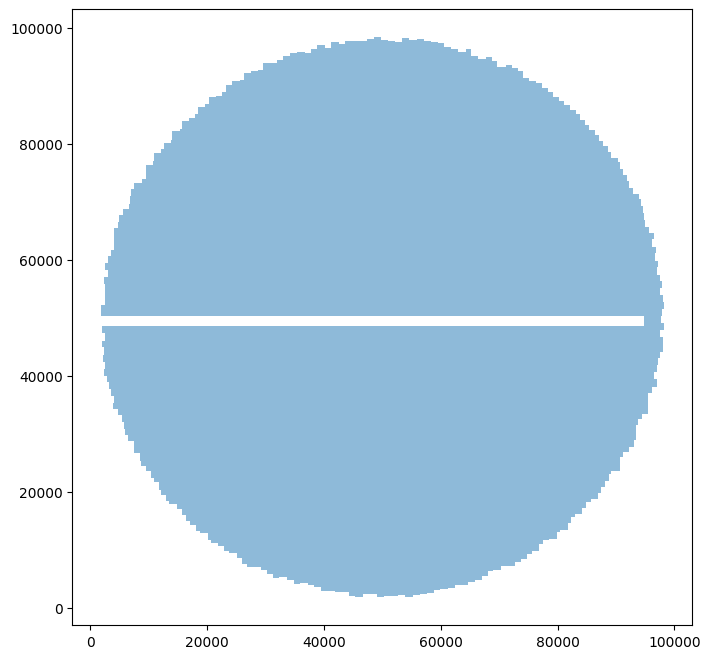

In [18]:
plt.figure(figsize=(8,8))
plt.fill(xs, ys, alpha=0.5)
plt.show()

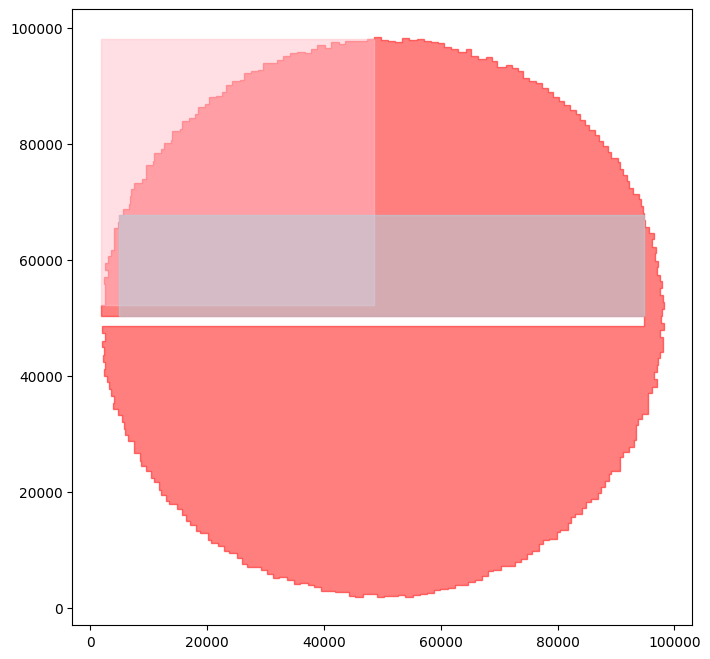

In [223]:
# (83829, 85218) (16274, 14908)
# (83829, 85218) (12867, 18347)
# (48515, 98075) (1725, 52189)
# (5529, 67739) (94710, 50238)
# (4890, 67739) (94710, 50238)

plt.figure(figsize=(8,8))
plt.fill(xs, ys, alpha=0.5, color="red")
# plt.fill([83829, 83829, 16274, 16274], [85218, 14908, 14908, 85218], color="green", alpha=0.5)
# plt.fill([83829, 83829, 12867, 12867], [85218, 18347, 18347, 85218], color="orange", alpha=0.5)
plt.fill([48515, 48515, 1725, 1725], [98075, 52189, 52189, 98075], color="pink", alpha=0.5)
# plt.fill([5529, 5529, 94710, 94710], [67739, 50238, 50238, 67739], color="purple", alpha=0.5)
plt.fill([4890, 4890, 94710, 94710], [67739, 50238, 50238, 67739], color="lightblue", alpha=0.5)
plt.show()


In [14]:
def get_area(p1, p2):
    return (abs(p1[0] - p2[0]) + 1) * (abs(p1[1] - p2[1]) + 1)

area = get_area((xs[23], ys[23]), (xs[249], ys[249]))

In [15]:
get_area((1,1), (4,4))

16

Check whether all points of the rectangle are within or on the boundary. [Ray casting algorithm](https://en.wikipedia.org/wiki/Point_in_polygon#:~:text=Ray%20casting%20algorithm,-See%20also%3A%20Jordan&text=The%20number%20of%20intersections%20for,also%20works%20in%20three%20dimensions.).